<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/BA820_M4_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Load Data and Basic Information**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from google.colab import files


In [ ]:
cats_uk = pd.read_csv("/content/sample_data/cats_uk.csv")
cats_uk_ref = pd.read_csv("/content/sample_data/cats_uk_reference.csv")

In [ ]:
print("cats_uk shape:", cats_uk.shape)
print("cats_uk_ref shape:", cats_uk_ref.shape)

print("\ncats_uk columns:\n", cats_uk.columns.tolist())
print("\ncats_uk_ref columns:\n", cats_uk_ref.columns.tolist())

key_e = ["tag_id","timestamp","location_lat","location_long","ground_speed",
         "algorithm_marked_outlier","manually_marked_outlier"]
key_r = ["tag_id","age_years","hrs_indoors","prey_p_month"]

print("\nMissing rate (events key cols):")
print(cats_uk[[c for c in key_e if c in cats_uk.columns]].isna().mean().sort_values(ascending=False))

print("\nMissing rate (ref key cols):")
print(cats_uk_ref[[c for c in key_r if c in cats_uk_ref.columns]].isna().mean().sort_values(ascending=False))

cats_uk shape: (18215, 11)
cats_uk_ref shape: (101, 16)

cats_uk columns:
 ['tag_id', 'event_id', 'visible', 'timestamp', 'location_long', 'location_lat', 'ground_speed', 'height_above_ellipsoid', 'algorithm_marked_outlier', 'manually_marked_outlier', 'study_name']

cats_uk_ref columns:
 ['tag_id', 'animal_id', 'animal_taxon', 'deploy_on_date', 'deploy_off_date', 'hunt', 'prey_p_month', 'animal_reproductive_condition', 'animal_sex', 'hrs_indoors', 'n_cats', 'food_dry', 'food_wet', 'food_other', 'study_site', 'age_years']

Missing rate (events key cols):
tag_id                      0.0
timestamp                   0.0
location_lat                0.0
location_long               0.0
ground_speed                0.0
algorithm_marked_outlier    0.0
manually_marked_outlier     0.0
dtype: float64

Missing rate (ref key cols):
age_years       0.009901
tag_id          0.000000
hrs_indoors     0.000000
prey_p_month    0.000000
dtype: float64


In [ ]:
#1.1 n_events,n_cats
n_events = len(cats_uk)
n_cats = cats_uk["tag_id"].nunique()
print("n_events:", n_events)
print("n_cats:", n_cats)

n_events: 18215
n_cats: 101


In [ ]:
#1.2 time range
cats_uk["timestamp"] = pd.to_datetime(cats_uk["timestamp"], errors="coerce")
tmin, tmax = cats_uk["timestamp"].min(), cats_uk["timestamp"].max()
print("min timestamp:", tmin)
print("max timestamp:", tmax)

min timestamp: 2017-06-03 01:02:09+00:00
max timestamp: 2017-11-30 00:52:55+00:00


In [ ]:
#1.3 events per cat
events_per_cat = cats_uk.groupby("tag_id").size().sort_values(ascending=False)
print("min:", int(events_per_cat.min()))
print("median:", float(events_per_cat.median()))
print("max:", int(events_per_cat.max()))

min: 12
median: 155.0
max: 963


In [ ]:
#1.4 top10
top10_share = events_per_cat.head(10).sum() / events_per_cat.sum()
print(f"{top10_share:.4f} ({top10_share*100:.2f}%)")

0.2765 (27.65%)


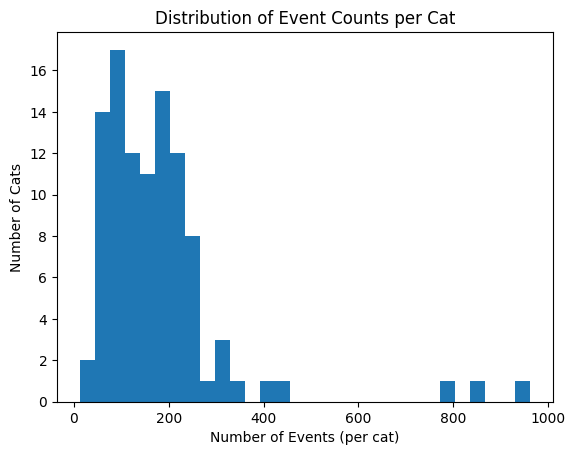

In [ ]:
#1.5 Plot distribution of events per cat
plt.figure()
plt.hist(events_per_cat.values, bins=30)
plt.title("Distribution of Event Counts per Cat")
plt.xlabel("Number of Events (per cat)")
plt.ylabel("Number of Cats")
plt.show()


**2.Convert Extreme Events to cat-level extreme_rate**

In [ ]:
#2.1 set thresholds for M4 sensitivity test
speed_col = "ground_speed"
cat_col = "tag_id"

tmp = cats_uk.dropna(subset=[speed_col, cat_col]).copy()

q_list = [0.90, 0.95, 0.99]
threshold_dict = {}

for q in q_list:
    threshold = tmp[speed_col].quantile(q)
    threshold_dict[q] = threshold
    print(f"{int(q*100)}th percentile threshold: {threshold:.4f}")


90th percentile threshold: 4140.0000
95th percentile threshold: 6156.0000
99th percentile threshold: 14214.9600


In [ ]:
#2.2 define event-level extreme for each threshold


extreme_rate_dict = {}
summary_rows = []

for q in q_list:
    threshold = threshold_dict[q]
    tmp_q = tmp.copy()
    tmp_q["is_extreme"] = (tmp_q[speed_col] >= threshold).astype(int)

    event_rate = tmp_q["is_extreme"].mean()

    summary_rows.append({
        "q": q,
        "threshold": float(threshold),
        "event_level_extreme_rate": float(event_rate)
    })

summary_event = pd.DataFrame(summary_rows).sort_values("q")
summary_event


,q,threshold,event_level_extreme_rate
0,0.90,4140.00,0.100302
1,0.95,6156.00,0.050343
2,0.99,14214.96,0.010047


In [ ]:
#2.3 convert to cat-level feature (extreme_rate per cat)

summary_rows_cat = []

for q in q_list:
    threshold = threshold_dict[q]
    tmp_q = tmp.copy()
    tmp_q["is_extreme"] = (tmp_q[speed_col] >= threshold).astype(int)

    extreme_rate_by_cat = tmp_q.groupby(cat_col)["is_extreme"].mean()
    extreme_rate_by_cat.name = f"extreme_rate_q{int(q*100)}"
    extreme_rate_dict[q] = extreme_rate_by_cat

    summary_rows_cat.append({
        "q": q,
        "mean_extreme_rate": float(extreme_rate_by_cat.mean()),
        "median_extreme_rate": float(extreme_rate_by_cat.median()),
        "max_extreme_rate": float(extreme_rate_by_cat.max()),
        "n_cats": int(extreme_rate_by_cat.shape[0])
    })

summary_cat = pd.DataFrame(summary_rows_cat).sort_values("q")
summary_cat


,q,mean_extreme_rate,median_extreme_rate,max_extreme_rate,n_cats
0,0.90,0.112710,0.102857,0.416667,101
1,0.95,0.057932,0.048193,0.333333,101
2,0.99,0.011056,0.009174,0.067568,101


In [ ]:
# sanity check: which cats have the highest extreme-rate under each threshold?
for q in q_list:
    print("\nq =", q)
    display(extreme_rate_dict[q].sort_values(ascending=False).head(5))



q = 0.9


,extreme_rate_q90
tag_id,
Magic-Tag,0.416667
Millie-Tag,0.234742
Gracie-Tag,0.204819
Lola,0.200893
Seb-Tag,0.197248



q = 0.95


,extreme_rate_q95
tag_id,
Magic-Tag,0.333333
Bobs-Tag,0.135135
CJ-Tag,0.126263
Gracie-Tag,0.120482
Felix-Tag,0.117647



q = 0.99


,extreme_rate_q99
tag_id,
Bobs-Tag,0.067568
Lily-Tag,0.065217
Felix-Tag,0.058824
Jasper-Tag,0.042105
CJ-Tag,0.040404


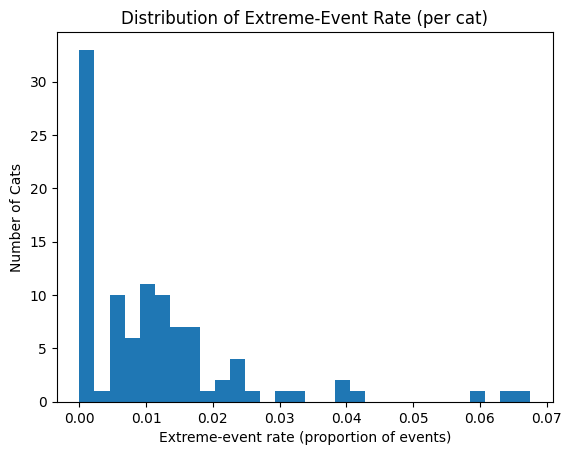

In [ ]:
#2.4 plot distribution of extreme_rate across cats
plt.figure()
plt.hist(extreme_rate_by_cat.values, bins=30)
plt.title("Distribution of Extreme-Event Rate (per cat)")
plt.xlabel("Extreme-event rate (proportion of events)")
plt.ylabel("Number of Cats")
plt.show()

In [ ]:
#2.5 Top 10 cats by extreme_rate (M4 baseline q=0.95)
q_base = 0.95
top10 = extreme_rate_dict[q_base].sort_values(ascending=False).head(10)
top10


,extreme_rate_q95
tag_id,
Magic-Tag,0.333333
Bobs-Tag,0.135135
CJ-Tag,0.126263
Gracie-Tag,0.120482
Felix-Tag,0.117647
Maggie-Tag,0.115385
Dexter2-Tag,0.112069
Lily-Tag,0.108696
Lola,0.107143


**3.Cat-level Aggregated Movement Features**

In [ ]:
#3.1 cleaning
df = cats_uk.copy()
cat_col = "tag_id"
time_col = "timestamp"
lat_col = "location_lat"
lon_col = "location_long"
speed_col = "ground_speed"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
df = df.dropna(subset=[cat_col, time_col])
df = df.dropna(subset=[lat_col, lon_col])

In [ ]:
#3.2 time feature
df["hour"] = df[time_col].dt.hour
df["is_day"] = ((df["hour"] >= 6) & (df["hour"] < 18)).astype(int)

In [ ]:
#3.3 quantiles
def q75(x):
    return x.quantile(0.75)

def q95(x):
    return x.quantile(0.95)

In [ ]:
#3.4 aggregate to cat-level features
X_cat_features = df.groupby(cat_col).agg(
    n_obs=(cat_col, "size"),
    mean_speed=(speed_col, "mean"),
    median_speed=(speed_col, "median"),
    max_speed=(speed_col, "max"),
    p75_speed=(speed_col, q75),
    p95_speed=(speed_col, q95),
    lat_span=(lat_col, lambda x: x.max() - x.min()),
    lon_span=(lon_col, lambda x: x.max() - x.min()),
    day_ratio=("is_day", "mean"),
).sort_index()

print("X_cat_features shape:", X_cat_features.shape)
print("Columns:", X_cat_features.columns.tolist())
X_cat_features.head()

X_cat_features shape: (101, 9)
Columns: ['n_obs', 'mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio']


,n_obs,mean_speed,median_speed,max_speed,p75_speed,p95_speed,lat_span,lon_span,day_ratio
tag_id,,,,,,,,,
Abba-Tag,83,1603.951807,864.0,13968,1746.0,5763.6,0.003963,0.010782,0.361446
Alfie-Tag,187,1931.679144,1188.0,14652,2358.0,5752.8,0.004066,0.012550,0.395722
Amber-Tag,218,1967.614679,1188.0,21888,2475.0,6438.6,0.030289,0.040155,0.655963
Ares,103,2285.825243,1440.0,14328,2898.0,7891.2,0.002487,0.003378,0.213592
Athena,106,2134.188679,1494.0,19728,2862.0,5715.0,0.002319,0.003988,0.452830


In [ ]:
#3.5 check missing
print("\nMissing rate in X_cat_features")
missing_rate = X_cat_features.isna().mean().sort_values(ascending=False)
print(missing_rate)

print("\nCats with any missing values:", X_cat_features.isna().any(axis=1).sum())

print("\nMissing counts by column")
print(X_cat_features.isna().sum().sort_values(ascending=False))


Missing rate in X_cat_features
n_obs           0.0
mean_speed      0.0
median_speed    0.0
max_speed       0.0
p75_speed       0.0
p95_speed       0.0
lat_span        0.0
lon_span        0.0
day_ratio       0.0
dtype: float64

Cats with any missing values: 0

Missing counts by column
n_obs           0
mean_speed      0
median_speed    0
max_speed       0
p75_speed       0
p95_speed       0
lat_span        0
lon_span        0
day_ratio       0
dtype: int64


In [ ]:
#3.6 Drop cats with missing speed-based features
speed_cols = ["mean_speed", "median_speed", "max_speed", "p75_speed", "p95_speed"]
X_cat_features_clean = X_cat_features.dropna(subset=speed_cols).copy()

print("\nAfter dropping cats with missing speed features:")
print("Shape:", X_cat_features_clean.shape)


After dropping cats with missing speed features:
Shape: (101, 9)


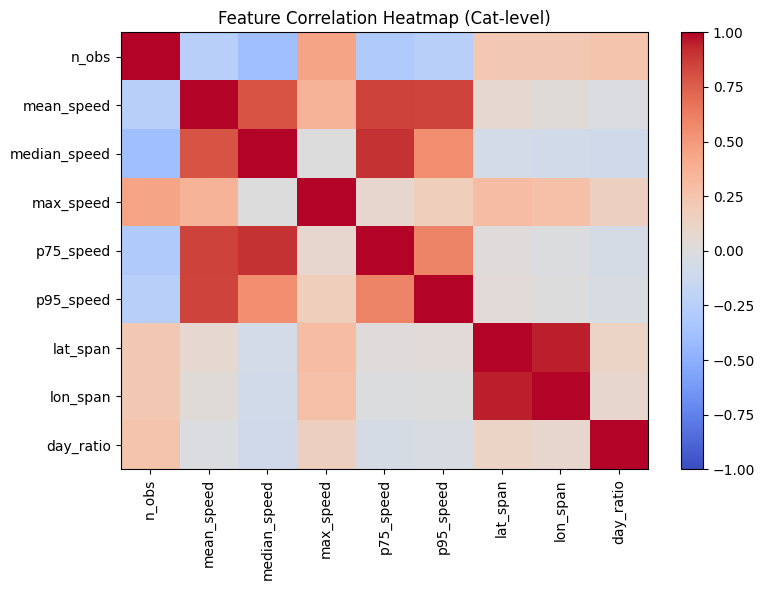

In [ ]:
#3.7 Correlation Heatmap
corr = X_cat_features_clean.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature Correlation Heatmap (Cat-level)")
plt.tight_layout()
plt.show()


**4. Normalized Hourly Activity Profiles**

In [ ]:
#4.1 cleaning
df = cats_uk.copy()

cat_col = "tag_id"
time_col = "timestamp"

df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
df = df.dropna(subset=[cat_col, time_col])

df["hour"] = df[time_col].dt.hour

In [ ]:
#4.2hourly counts per cat for 24h dimensions
hourly_counts = (
    df
    .groupby([cat_col, "hour"])
    .size()
    .reset_index(name="count")
)

In [ ]:
#4.3 normalizing
hourly_counts["norm_count"] = (
    hourly_counts
    .groupby(cat_col)["count"]
    .transform(lambda x: x / x.sum())
)

In [ ]:
#4.4 feature refinement
hourly_matrix = (
    hourly_counts
    .pivot(index=cat_col, columns="hour", values="norm_count")
    .fillna(0)
)
hourly_matrix = hourly_matrix.reindex(columns=range(24), fill_value=0)

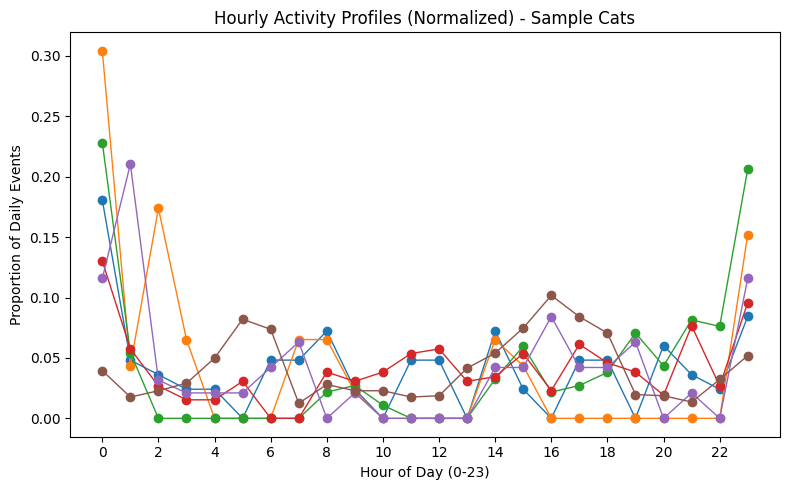

In [ ]:
#4.5random profile
np.random.seed(42)
sample_cats = np.random.choice(hourly_matrix.index, size=6, replace=False)

plt.figure(figsize=(8, 5))
for cid in sample_cats:
    plt.plot(range(24), hourly_matrix.loc[cid].values, marker="o", linewidth=1)

plt.title("Hourly Activity Profiles (Normalized) - Sample Cats")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Proportion of Daily Events")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()



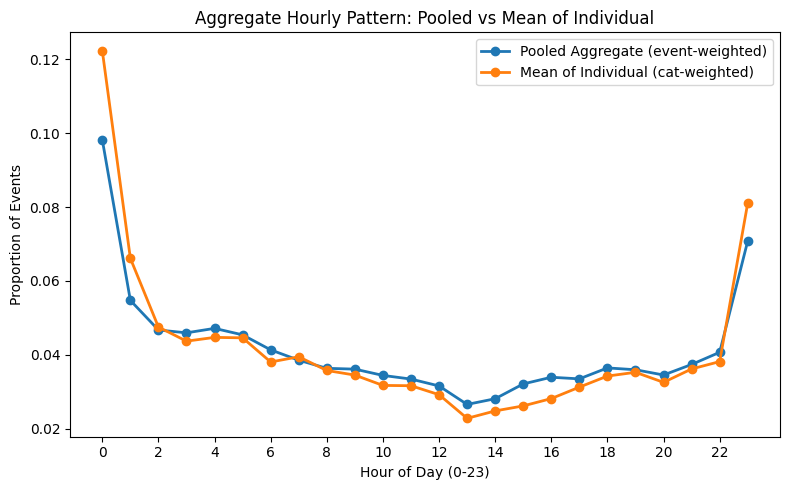

L1 difference (pooled vs mean-individual): 0.0950037070860486


In [ ]:
#4.6pooled aggregate vs mean-of-individua
# pooled aggregate (event-weighted)
pooled_counts = df.groupby("hour").size().reindex(range(24), fill_value=0)
pooled_profile = pooled_counts / pooled_counts.sum()

# mean of individual (cat-weighted)
mean_individual_profile = hourly_matrix.mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(range(24), pooled_profile.values, marker="o", linewidth=2, label="Pooled Aggregate (event-weighted)")
plt.plot(range(24), mean_individual_profile.values, marker="o", linewidth=2, label="Mean of Individual (cat-weighted)")
plt.title("Aggregate Hourly Pattern: Pooled vs Mean of Individual")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Proportion of Events")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()
plt.show()

l1_diff = np.abs(pooled_profile.values - mean_individual_profile.values).sum()
print("L1 difference (pooled vs mean-individual):", l1_diff)



In [ ]:
#4.7 check
print(hourly_matrix.shape)
print(hourly_matrix.sum(axis=1).head())

(101, 24)
tag_id
Abba-Tag     1.0
Alfie-Tag    1.0
Amber-Tag    1.0
Ares         1.0
Athena       1.0
dtype: float64


**5.Merge into Integrated Analysis Table**

In [ ]:
q_base = 0.95
extreme_tbl = extreme_rate_dict[q_base].to_frame(name="extreme_rate")


In [ ]:
#5.2Prepare attributes table
attr_cols = ["tag_id", "age_years", "hrs_indoors", "prey_p_month"]
attr_cols = [c for c in attr_cols if c in cats_uk_ref.columns]  # safety
attr_tbl = cats_uk_ref[attr_cols].copy()

In [ ]:
#5.3 build cat table
cat_table = (
    X_cat_features
    .join(extreme_tbl, how="left")
    .reset_index()
    .rename(columns={"index": "tag_id"})
)
if "tag_id" not in cat_table.columns and X_cat_features.index.name == "tag_id":
    cat_table = cat_table.rename(columns={X_cat_features.index.name: "tag_id"})

cat_table = cat_table.merge(attr_tbl, on="tag_id", how="left")
print("cat_table shape:", cat_table.shape)
print("cat_table columns:", cat_table.columns.tolist())

cat_table shape: (101, 14)
cat_table columns: ['tag_id', 'n_obs', 'mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio', 'extreme_rate', 'age_years', 'hrs_indoors', 'prey_p_month']


In [ ]:
#5.4 Define clustering columns
attr_features = [c for c in ["age_years", "hrs_indoors", "prey_p_month"]
                 if c in cat_table.columns]

cluster_cols = [c for c in cat_table.columns
                if c not in ["tag_id"] + attr_features]

if "n_obs" in cluster_cols:
    cluster_cols.remove("n_obs")

print("Clustering features (used in X_cluster):")
print(cluster_cols)

print("Attributes (for interpretation only, NOT used in X_cluster):")
print(attr_features)

Clustering features (used in X_cluster):
['mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio', 'extreme_rate']
Attributes (for interpretation only, NOT used in X_cluster):
['age_years', 'hrs_indoors', 'prey_p_month']


In [ ]:
#5.5 check missing
X_df = cat_table[["tag_id"] + cluster_cols].copy()
print("\nMissing counts in clustering columns:")
print(X_df[cluster_cols].isna().sum().sort_values(ascending=False))

X_df_clean = X_df.dropna(subset=cluster_cols).copy()
print("\nAfter dropna, n_cats for clustering:", X_df_clean.shape[0])


Missing counts in clustering columns:
mean_speed      0
median_speed    0
max_speed       0
p75_speed       0
p95_speed       0
lat_span        0
lon_span        0
day_ratio       0
extreme_rate    0
dtype: int64

After dropna, n_cats for clustering: 101


In [ ]:
#5.6 StandardScaler
scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_df_clean[cluster_cols])
print("X_cluster shape:", X_cluster.shape)

X_cluster shape: (101, 9)


In [ ]:
#5.7 Keep a clean table aligned with X_cluster rows
cat_table_clean = cat_table.merge(X_df_clean[["tag_id"]], on="tag_id", how="inner").copy()

In [ ]:
#5.8 Markdown-style column list
print("Clustering features (used in X_cluster):")
print(cluster_cols)
print("Attributes (for interpretation only, NOT used in X_cluster):")
print(attr_features)

Clustering features (used in X_cluster):
['mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio', 'extreme_rate']
Attributes (for interpretation only, NOT used in X_cluster):
['age_years', 'hrs_indoors', 'prey_p_month']


In [ ]:
print("q_list:", q_list)
print("extreme_rate_dict keys:", list(extreme_rate_dict.keys()))
print("X_cat_features shape:", X_cat_features.shape)
print("attr_tbl shape:", attr_tbl.shape)
print("cluster_cols:", cluster_cols)
print("X_cluster shape:", X_cluster.shape)


q_list: [0.9, 0.95, 0.99]
extreme_rate_dict keys: [0.9, 0.95, 0.99]
X_cat_features shape: (101, 9)
attr_tbl shape: (101, 4)
cluster_cols: ['mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio', 'extreme_rate']
X_cluster shape: (101, 9)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for q in q_list:

    extreme_tbl_q = extreme_rate_dict[q].to_frame(name="extreme_rate")

    cat_table_q = (
        X_cat_features
        .join(extreme_tbl_q, how="left")
        .reset_index()
        .rename(columns={"index": "tag_id"})
    )
    cat_table_q = cat_table_q.merge(attr_tbl, on="tag_id", how="left")

    attr_features_q = [c for c in ["age_years", "hrs_indoors", "prey_p_month"] if c in cat_table_q.columns]
    cluster_cols_q = [c for c in cat_table_q.columns if c not in ["tag_id"] + attr_features_q]
    if "n_obs" in cluster_cols_q:
        cluster_cols_q.remove("n_obs")

    X_df_q = cat_table_q[["tag_id"] + cluster_cols_q].dropna(subset=cluster_cols_q).copy()
    X_q = StandardScaler().fit_transform(X_df_q[cluster_cols_q])

    for k in [2, 3]:

        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_km = km.fit_predict(X_q)
        sil_km = silhouette_score(X_q, labels_km)
        sizes_km = pd.Series(labels_km).value_counts().sort_index().to_list()

        results.append({
            "q": q,
            "model": "KMeans",
            "k": k,
            "silhouette": sil_km,
            "cluster_sizes": sizes_km,
            "n_cats_used": X_q.shape[0]
        })

        gmm = GaussianMixture(n_components=k, random_state=42)
        labels_gmm = gmm.fit_predict(X_q)
        sil_gmm = silhouette_score(X_q, labels_gmm)
        sizes_gmm = pd.Series(labels_gmm).value_counts().sort_index().to_list()

        results.append({
            "q": q,
            "model": "GMM",
            "k": k,
            "silhouette": sil_gmm,
            "cluster_sizes": sizes_gmm,
            "n_cats_used": X_q.shape[0]
        })

results_df = pd.DataFrame(results).sort_values(["q", "model", "k"]).reset_index(drop=True)
results_df


,q,model,k,silhouette,cluster_sizes,n_cats_used
0,0.90,GMM,2,0.268952,"[77, 24]",101
1,0.90,GMM,3,0.246269,"[74, 24, 3]",101
2,0.90,KMeans,2,0.322620,"[61, 40]",101
3,0.90,KMeans,3,0.344867,"[36, 62, 3]",101
4,0.95,GMM,2,0.344586,"[79, 22]",101
5,0.95,GMM,3,0.243585,"[74, 24, 3]",101
6,0.95,KMeans,2,0.367949,"[73, 28]",101
7,0.95,KMeans,3,0.377067,"[72, 26, 3]",101
8,0.99,GMM,2,0.397172,"[83, 18]",101
9,0.99,GMM,3,0.382339,"[82, 14, 5]",101


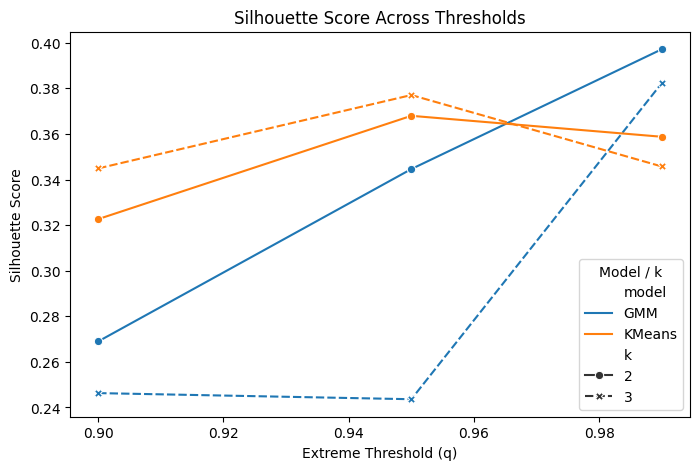

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.lineplot(
    data=results_df,
    x="q",
    y="silhouette",
    hue="model",
    style="k",
    markers=True
)

plt.title("Silhouette Score Across Thresholds")
plt.xlabel("Extreme Threshold (q)")
plt.ylabel("Silhouette Score")
plt.legend(title="Model / k")
plt.show()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

assignments = {}

for q in q_list:

    extreme_tbl_q = extreme_rate_dict[q].to_frame(name="extreme_rate")

    cat_table_q = (
        X_cat_features
        .join(extreme_tbl_q, how="left")
        .reset_index()
        .rename(columns={"index": "tag_id"})
    )
    cat_table_q = cat_table_q.merge(attr_tbl, on="tag_id", how="left")

    attr_features_q = [c for c in ["age_years", "hrs_indoors", "prey_p_month"] if c in cat_table_q.columns]
    cluster_cols_q = [c for c in cat_table_q.columns if c not in ["tag_id"] + attr_features_q]
    if "n_obs" in cluster_cols_q:
        cluster_cols_q.remove("n_obs")

    X_df_q = cat_table_q[["tag_id"] + cluster_cols_q].dropna(subset=cluster_cols_q).copy()
    X_q = StandardScaler().fit_transform(X_df_q[cluster_cols_q])

    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = km.fit_predict(X_q)

    assignments[q] = pd.Series(labels, index=X_df_q["tag_id"])


assignment_df = pd.DataFrame(assignments)
assignment_df.head()


,0.90,0.95,0.99
tag_id,,,
Abba-Tag,0,0,0
Alfie-Tag,0,0,0
Amber-Tag,0,0,0
Ares,1,1,1
Athena,1,0,0


In [ ]:
# Show which cats change cluster between thresholds (no stability metric)

change_90_95 = assignment_df[assignment_df[0.90] != assignment_df[0.95]]
change_95_99 = assignment_df[assignment_df[0.95] != assignment_df[0.99]]
change_90_99 = assignment_df[assignment_df[0.90] != assignment_df[0.99]]

print("Changed cats: 90 vs 95")
display(change_90_95)

print("Changed cats: 95 vs 99")
display(change_95_99)

print("Changed cats: 90 vs 99")
display(change_90_99)

Changed cats: 90 vs 95


,0.90,0.95,0.99
tag_id,,,
Athena,1,0,0
Charlie3-Tag,1,0,0
Chloe-Tag,1,0,0
Dory-Tag,1,0,0
Frank_2-Tag,1,0,0
Freya-Tag,1,0,0
Missy-Tag,1,0,0
Pants-Tag,1,0,0
SmokeyLongnose-Tag,1,0,0


Changed cats: 95 vs 99


,0.90,0.95,0.99
tag_id,,,


Changed cats: 90 vs 99


,0.90,0.95,0.99
tag_id,,,
Athena,1,0,0
Charlie3-Tag,1,0,0
Chloe-Tag,1,0,0
Dory-Tag,1,0,0
Frank_2-Tag,1,0,0
Freya-Tag,1,0,0
Missy-Tag,1,0,0
Pants-Tag,1,0,0
SmokeyLongnose-Tag,1,0,0


**6.Clustering A(Behavior Summary)**

**6.1 Hierarchical clustering**

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
cat_ids = X_df_clean["tag_id"].values
Z = linkage(X_cluster, method="ward")
print("Linkage matrix:", Z.shape)

Linkage matrix: (100, 4)


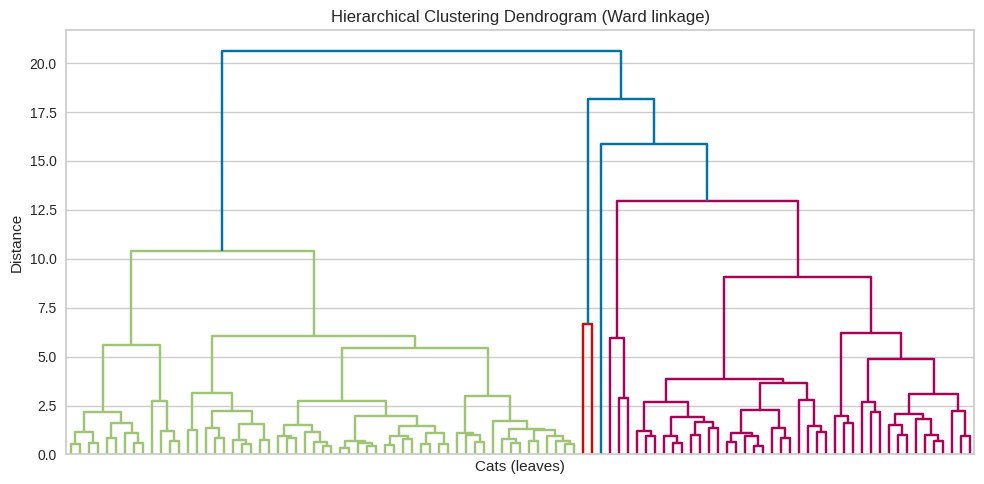

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Cats (leaves)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
n_clusters = 2

labels = fcluster(Z, t=n_clusters, criterion="maxclust").astype(int)

df_hc2 = pd.DataFrame({"tag_id": cat_ids, "cluster_labels": labels.astype(str)})

print(df_hc2["cluster_labels"].value_counts().sort_index())

cluster_labels
1    57
2    44
Name: count, dtype: int64


In [ ]:
n_clusters = 3

labels = fcluster(Z, t=n_clusters, criterion="maxclust").astype(int)

df_hc3 = pd.DataFrame({"tag_id": cat_ids, "cluster_labels": labels.astype(str)})

print(df_hc3["cluster_labels"].value_counts().sort_index())

cluster_labels
1    57
2     2
3    42
Name: count, dtype: int64


In [ ]:
n_clusters = 4

labels = fcluster(Z, t=n_clusters, criterion="maxclust").astype(int)

df_hc4 = pd.DataFrame({"tag_id": cat_ids, "cluster_labels": labels.astype(str)})

print(df_hc4["cluster_labels"].value_counts().sort_index())

cluster_labels
1    57
2     2
3    41
4     1
Name: count, dtype: int64


In [ ]:
sizes = pd.DataFrame({
    "k2": df_hc2["cluster_labels"].value_counts().sort_index(),
    "k3": df_hc3["cluster_labels"].value_counts().sort_index(),
    "k4": df_hc4["cluster_labels"].value_counts().sort_index(),
}).fillna(0).astype(int)

sizes

,k2,k3,k4
cluster_labels,,,
1,57,57,57
2,44,2,2
3,0,42,41
4,0,0,1


**6.2 K-means**

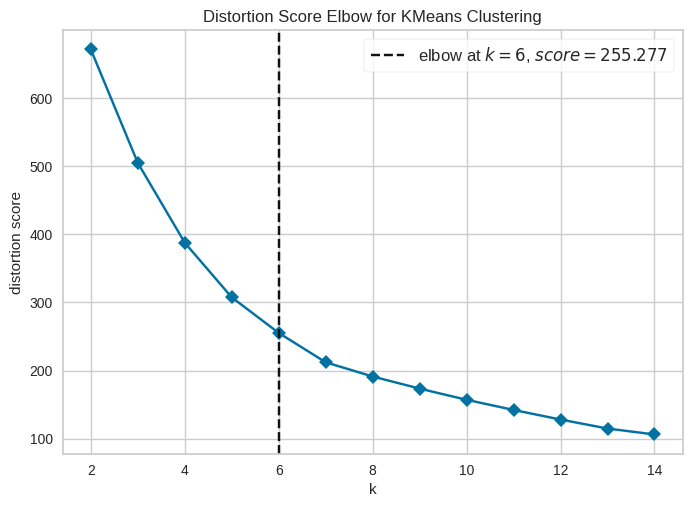

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
#6.2.1 Elbow Plot
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42, n_init=20)

visualizer = KElbowVisualizer(
    model,
    k=(2, 15),
    metric='distortion',
    timings=False
)

visualizer.fit(X_cluster)
visualizer.show()


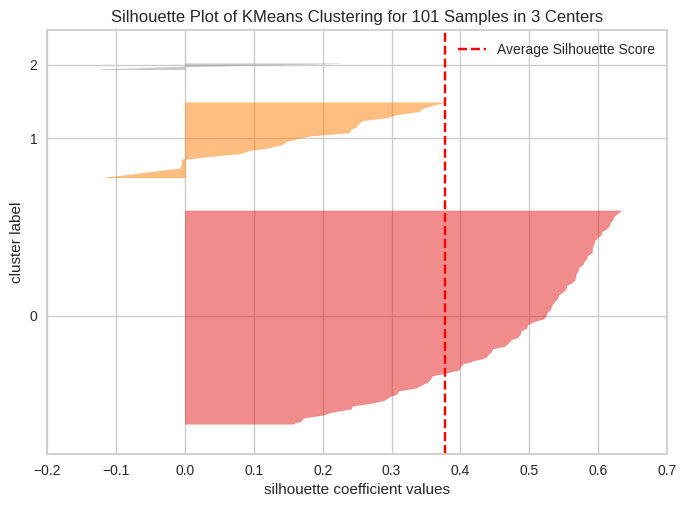

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 101 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# 6.2.2 Silhouette Plot
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

n_clusters_kmeans = 3
kmeans_model = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=20)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)
visualizer.fit(X_cluster)
visualizer.show()



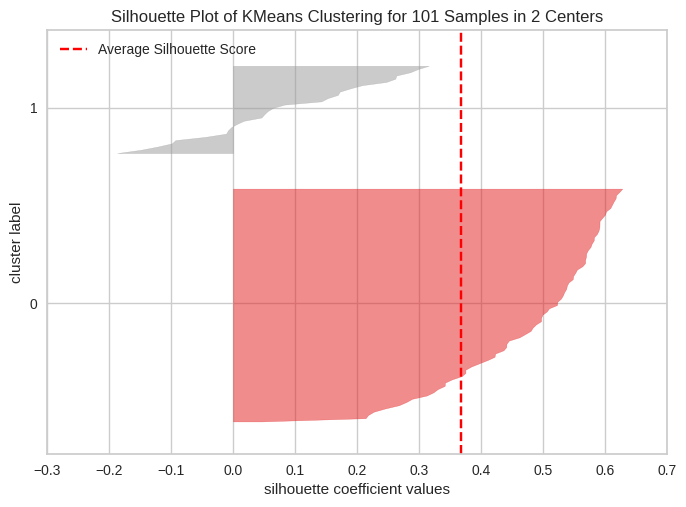

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 101 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
n_clusters_kmeans = 2
kmeans_model = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=20)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)
visualizer.fit(X_cluster)
visualizer.show()

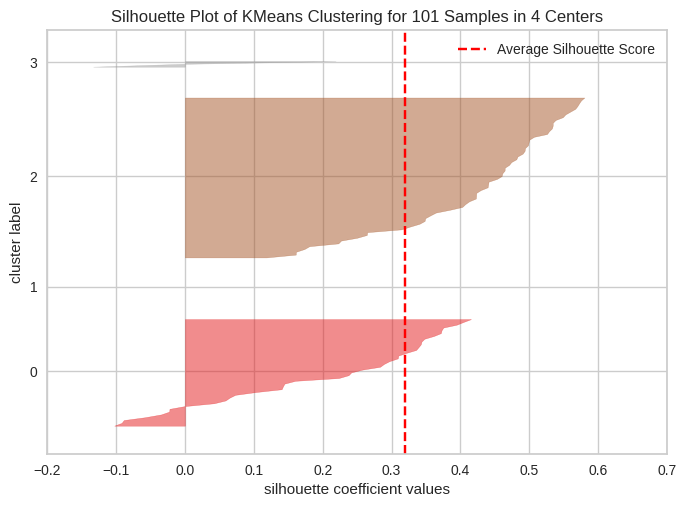

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 101 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
n_clusters_kmeans = 4
kmeans_model = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=20)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)
visualizer.fit(X_cluster)
visualizer.show()

In [ ]:
size_table = {}

for k in [2,3,4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_cluster)
    size_table[f"k={k}"] = pd.Series(labels).value_counts().sort_index()

pd.DataFrame(size_table).fillna(0).astype(int)

,k=2,k=3,k=4
0,73,72,39
1,28,26,1
2,0,3,58
3,0,0,3


**7.Clustering B(Hourly Profiles)**


**7.1 Hierarchical clustering**

In [ ]:
df_hour = hourly_matrix.copy()
df_hour = df_hour.reindex(columns=range(24), fill_value=0)
cat_ids_hour = df_hour.index.values
X_hour = df_hour.values
Z_hour = linkage(X_hour, method="ward")
print("Linkage matrix:", Z_hour.shape)

Linkage matrix: (100, 4)


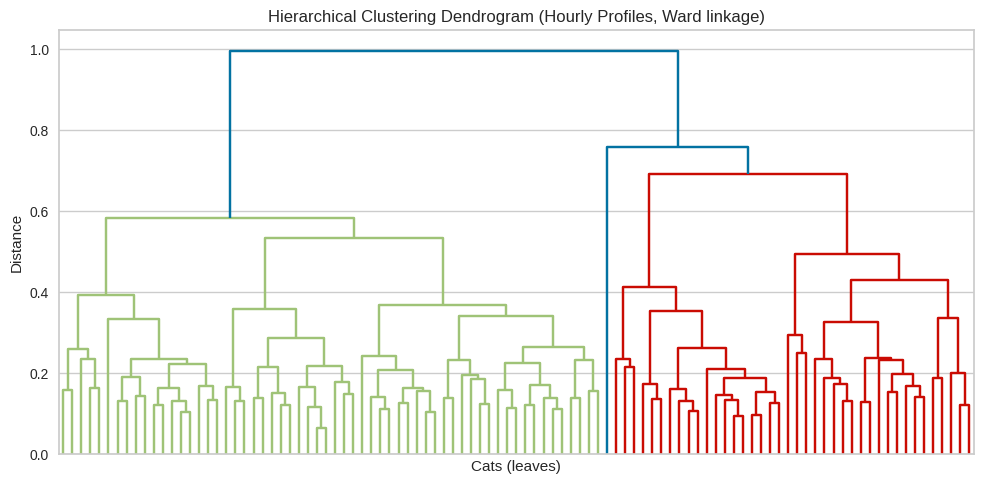

In [ ]:
plt.figure(figsize=(10, 5))
dendrogram(Z_hour, no_labels=True, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram (Hourly Profiles, Ward linkage)")
plt.xlabel("Cats (leaves)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
n_clusters = 2

labels = fcluster(Z_hour, t=n_clusters, criterion="maxclust").astype(int)

df_hc2_hour = pd.DataFrame({
    "tag_id": cat_ids_hour,
    "cluster_labels": labels.astype(str)
})

print(df_hc2_hour["cluster_labels"].value_counts().sort_index())


cluster_labels
1    60
2    41
Name: count, dtype: int64


In [ ]:
n_clusters = 3

labels = fcluster(Z_hour, t=n_clusters, criterion="maxclust").astype(int)

df_hc3_hour = pd.DataFrame({
    "tag_id": cat_ids_hour,
    "cluster_labels": labels.astype(str)
})

print(df_hc3_hour["cluster_labels"].value_counts().sort_index())

cluster_labels
1    60
2    40
3     1
Name: count, dtype: int64


In [ ]:
n_clusters = 4

labels = fcluster(Z_hour, t=n_clusters, criterion="maxclust").astype(int)

df_hc4_hour = pd.DataFrame({
    "tag_id": cat_ids_hour,
    "cluster_labels": labels.astype(str)
})

print(df_hc4_hour["cluster_labels"].value_counts().sort_index())


cluster_labels
1    60
2    19
3    21
4     1
Name: count, dtype: int64


In [ ]:
sizes_hour = (
    pd.DataFrame({
        "k2": df_hc2_hour["cluster_labels"].value_counts().sort_index(),
        "k3": df_hc3_hour["cluster_labels"].value_counts().sort_index(),
        "k4": df_hc4_hour["cluster_labels"].value_counts().sort_index()
    })
    .fillna(0)
    .astype(int)
)

sizes_hour

,k2,k3,k4
cluster_labels,,,
1,60,60,60
2,41,40,19
3,0,1,21
4,0,0,1


**7.2 K-means**

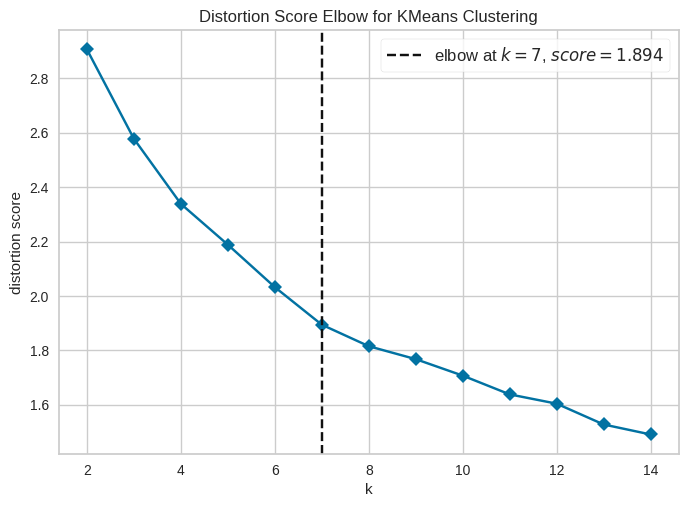

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# 7.2.1 Elbow Plot (Hourly Profiles)
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42, n_init=20)

visualizer = KElbowVisualizer(
    model,
    k=(2, 15),
    metric="distortion",
    timings=False
)

visualizer.fit(X_hour)
visualizer.show()


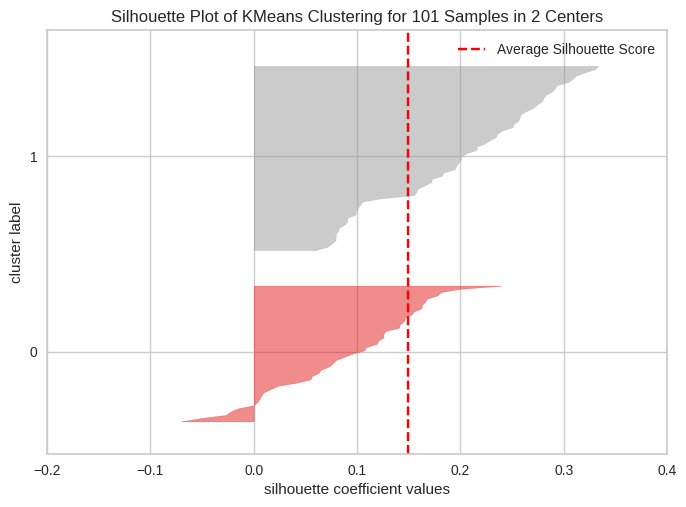

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 101 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# 7.2.2 Silhouette Plot
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

n_clusters_hour = 2
kmeans_hour = KMeans(n_clusters=n_clusters_hour, random_state=42, n_init=20)

visualizer = SilhouetteVisualizer(kmeans_hour, timings=False)
visualizer.fit(X_hour)
visualizer.show()


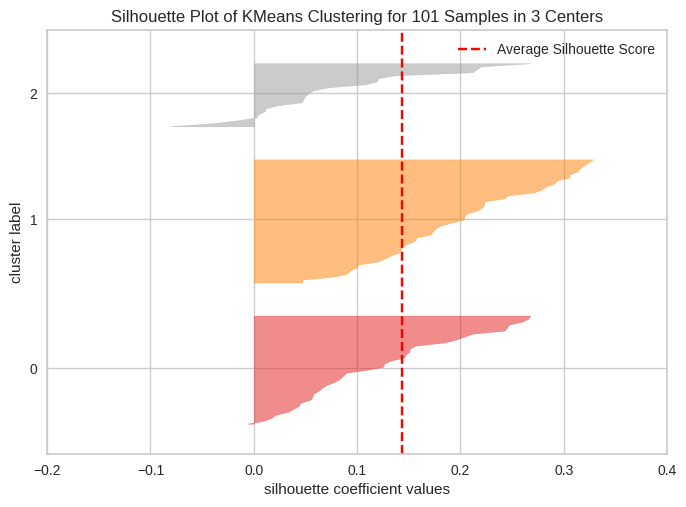

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 101 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
n_clusters_hour = 3
kmeans_hour = KMeans(n_clusters=n_clusters_hour, random_state=42, n_init=20)

visualizer = SilhouetteVisualizer(kmeans_hour, timings=False)
visualizer.fit(X_hour)
visualizer.show()


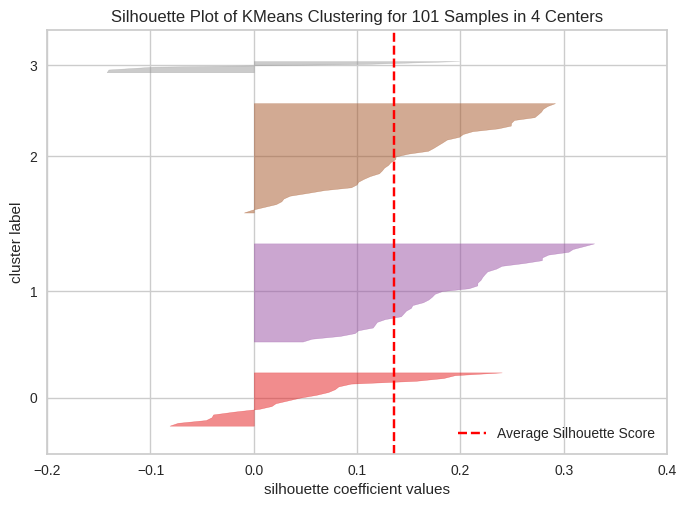

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 101 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
n_clusters_hour = 4
kmeans_hour = KMeans(n_clusters=n_clusters_hour, random_state=42, n_init=20)

visualizer = SilhouetteVisualizer(kmeans_hour, timings=False)
visualizer.fit(X_hour)
visualizer.show()


In [ ]:
size_table = {}

for k in [2,3,4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_hour)
    size_table[f"k={k}"] = pd.Series(labels).value_counts().sort_index()

pd.DataFrame(size_table).fillna(0).astype(int)

,k=2,k=3,k=4
0,43,37,20
1,58,42,36
2,0,22,40
3,0,0,5


**8.Compare robustness across methods**

In [ ]:
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans

k_final = 3

# Hierarchical labels
labels_hc = fcluster(Z, t=k_final, criterion="maxclust")

# KMeans labels
kmeans_model = KMeans(n_clusters=k_final, random_state=42, n_init=20)
labels_km = kmeans_model.fit_predict(X_cluster)


In [ ]:
import pandas as pd

cont_table = pd.crosstab(labels_hc, labels_km)

cont_table


col_0,0,1,2
row_0,,,
1,57,0,0
2,0,0,2
3,15,26,1


**9. Key Integrated Outputs**

In [ ]:
import os
import pandas as pd
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fcluster

k_final = 3

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
labels_km = kmeans_final.fit_predict(X_cluster)

labels_hc = fcluster(Z, t=k_final, criterion="maxclust")

cat_table_export = cat_table.copy()

if len(cat_table_export) != len(labels_km):
    raise ValueError(
        f"Row mismatch: cat_table has {len(cat_table_export)} rows "
        f"but clustering labels have {len(labels_km)} rows."
    )

cat_table_export["cluster_kmeans"] = labels_km
cat_table_export["cluster_hierarchical"] = labels_hc
cat_table_export["cluster_kmeans_1based"] = labels_km + 1

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "cat_table_with_clusters.csv")
cat_table_export.to_csv(output_path, index=False)

from google.colab import files
files.download(output_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>